# Fase 1 — Recolección de datos y separación train/test

**TP1 — Aprendizaje Automático (72.75) — ITBA** · Consigna **2.1**

**Qué hacemos:** cargamos el dataset y lo separamos en train y test.


In [1]:
# ---------------------------------------------------------------------------
# Configuracion del entorno
# ---------------------------------------------------------------------------
# Agregamos la raiz del repo al path para poder importar el paquete src/.
# En VS Code esto ya lo resuelve .vscode/settings.json, pero lo dejamos explicito
# para que el notebook tambien funcione ejecutado desde la terminal.
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():   # si estamos parados dentro de notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

# Constantes del proyecto: semilla, nombre del target y proporcion de test.
from src.config import RANDOM_SEED, TARGET, TEST_SIZE, FIGURES_DIR

# Funciones propias, documentadas en src/data.py
from src.data import (
    cargar_datos_crudos,   # lee el CSV y valida su estructura
    eliminar_duplicados,   # quita filas exactamente repetidas
    separar_train_test,    # parte el dataset en 80/20
    verificar_split,       # audita que la particion sea correcta
    guardar_splits,        # escribe train.csv y test.csv
)

pd.set_option("display.width", 110)
print(f"Semilla: {RANDOM_SEED} | Target: {TARGET} | Test: {TEST_SIZE:.0%}")

Semilla: 42 | Target: charges | Test: 20%


---

## 1. Carga de los datos

Leemos siempre desde `data/raw/insurance.csv`, nunca desde una API.

**Motivo:** `kagglehub` descarga la *última versión* publicada. Si esa versión cambiara,
los números de la presentación dejarían de reproducirse. El CSV está versionado en el
repositorio para congelar exactamente los datos que usamos.

In [2]:
# cargar_datos_crudos() lee el CSV y verifica que tenga las 7 columnas
# esperadas y 1338 filas. Si el archivo fuera otro, lanza un error explicito.
df = cargar_datos_crudos()

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 1338 filas x 7 columnas


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 1.1 Verificación estructural

Controlamos que el archivo sea el esperado. **No modificamos ni descartamos nada**

In [3]:
# Tipo de dato de cada columna.
print("--- Tipos de dato ---")
print(df.dtypes.to_string())

# Cantidad de valores nulos por columna.
print("\n--- Valores faltantes ---")
print(df.isna().sum().to_string())

# duplicated() marca filas repetidas; keep=False muestra todas las copias.
print(f"\n--- Filas exactamente duplicadas: {df.duplicated().sum()} ---")
display(df[df.duplicated(keep=False)])

--- Tipos de dato ---
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64

--- Valores faltantes ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0

--- Filas exactamente duplicadas: 1 ---


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


**Encontramos:**

- **0 valores faltantes** en las 7 columnas.
- **Un par de filas idénticas** (índices 195 y 581): misma edad, sexo, BMI, hijos,
  condición de fumador, región y costo. Lo tratamos en el punto siguiente.

### 1.2 Eliminación de duplicados exactos

**Decidimos eliminar la fila repetida antes de separar train y test.**

**El motivo:** si no lo hiciéramos, el sorteo podría mandar una copia a train y la otra a
test. En ese caso el test contendría un registro que el modelo ya vio al entrenar, y
dejaría de ser un conjunto de datos verdaderamente nuevos.

In [4]:
# eliminar_duplicados() conserva la primera aparicion de cada fila repetida.
# Devuelve el dataset limpio y cuantas filas se eliminaron.
df, n_duplicados = eliminar_duplicados(df)

print(f"Filas eliminadas por duplicado exacto: {n_duplicados}")
print(f"Dataset resultante: {len(df)} filas")

Filas eliminadas por duplicado exacto: 1
Dataset resultante: 1337 filas


---

## 2. Separación train/test

### 2.1 Por qué separamos antes de limpiar

El enunciado numera "1. Limpieza" antes de "2.1 Separación", pero ese es el orden en que
se explican las consignas, no el orden en que se ejecutan. El pipeline de la Clase 3
pone **Data Splitting en el paso 3, antes de la limpieza (paso 4)**.

**El motivo es el data leakage.** Si imputáramos un valor usando la mediana del dataset
completo, esa mediana contendría información de las filas que van a ir al test. El modelo
entrenaría con un número que resume datos que se supone nunca vio, y el error de test
dejaría de ser una estimación honesta: saldría **demasiado optimista**.

Lo mismo vale para el IQR de los outliers, la media y el desvío del escalado, y el
encoding de las categóricas.

### 2.2 Método y proporción

| Decisión | Valor | Motivo |
|---|---|---|
| Método | Muestreo aleatorio simple | Por lo visto en Clase 3|
| Proporción | 80% train / 20% test | Por lo visto en Clase 3|
| Dev set fijo | No usamos | Validamos con k-fold sobre el train  |
| Semilla | 42, en `src/config.py` | Sin ella cada ejecución daría otra partición y otro RMSE |

**Sobre la semilla:** la fijamos una sola vez y no la modificamos después. Probar varias
semillas y quedarse con la que da mejor resultado sería elegir la partición más
favorable en lugar del mejor modelo.

**Sobre el dev set:** la Clase 2 propone 60-20-20, con un dev fijo para elegir modelo.
Nosotros usamos 80-20 porque la validación la hace el k-fold dentro del train, que
aprovecha mejor los datos: cada fila se usa una vez para validar y el resto para entrenar.

**Elegimos 20%.** Con 15% el test queda en unas 200 filas, pocas para estimar el error de
forma estable. Con 30% le sacaríamos más de 130 filas al train sin ganar precisión
relevante. El 20% nos deja **1069 filas de train y 268 de test**.

### 2.3 Ejecución del split

In [5]:
# separar_train_test() usa train_test_split con shuffle y la semilla fija.
# Conserva el indice original del CSV para poder auditar cada fila.
train, test = separar_train_test(df)

print(f"Train: {train.shape[0]:5d} filas ({train.shape[0]/len(df):.1%})")
print(f"Test : {test.shape[0]:5d} filas ({test.shape[0]/len(df):.1%})")

Train:  1069 filas (80.0%)
Test :   268 filas (20.0%)


### 2.4 ¿El test representa la muestra?

La Clase 2 vimos que el test *"represente los datos reales en los que el modelo
se usará"*. El sorteo aleatorio lo cumple en promedio; verificamos que en esta partición
concreta no haya quedado ningún desbalance.

**Comparamos únicamente las variables de entrada, nunca el target.** La pregunta de la
representatividad es sobre la composición de los conjuntos: si `age`, `bmi`, `children`,
`sex`, `smoker` y `region` tienen distribuciones parecidas, el test es representativo.


In [6]:
# Comparamos media y desvio de cada variable de entrada numerica.
# El target NO se incluye: no se mira charges del test hasta la Fase 6.
num_cols = ["age", "bmi", "children"]

comparacion = pd.DataFrame({
    "train_media": train[num_cols].mean(),
    "test_media": test[num_cols].mean(),
    "train_desvio": train[num_cols].std(),
    "test_desvio": test[num_cols].std(),
})
# Diferencia porcentual entre las medias, para leerla de un vistazo.
comparacion["dif_medias_%"] = (
    100 * (comparacion["test_media"] - comparacion["train_media"]) / comparacion["train_media"]
)
comparacion.round(2)

,train_media,test_media,train_desvio,test_desvio,dif_medias_%
age,39.20,39.32,14.00,14.25,0.30
bmi,30.54,31.15,6.05,6.28,2.01
children,1.08,1.14,1.19,1.25,5.31


In [7]:
# Para las categoricas comparamos la proporcion de cada nivel (en %).
for col in ["sex", "smoker", "region"]:
    prop = pd.DataFrame({
        "train_%": 100 * train[col].value_counts(normalize=True),
        "test_%": 100 * test[col].value_counts(normalize=True),
    })
    prop["dif_pp"] = prop["test_%"] - prop["train_%"]   # diferencia en puntos porcentuales
    print(f"--- {col} ---")
    print(prop.round(2).to_string())
    print()

--- sex ---
        train_%  test_%  dif_pp
sex                            
female    48.55   53.36    4.81
male      51.45   46.64   -4.81

--- smoker ---
        train_%  test_%  dif_pp
smoker                         
no        79.98   77.61   -2.37
yes       20.02   22.39    2.37

--- region ---
           train_%  test_%  dif_pp
region                            
northeast    23.67   26.49    2.83
northwest    24.70   22.39   -2.31
southeast    26.85   28.73    1.88
southwest    24.79   22.39   -2.40



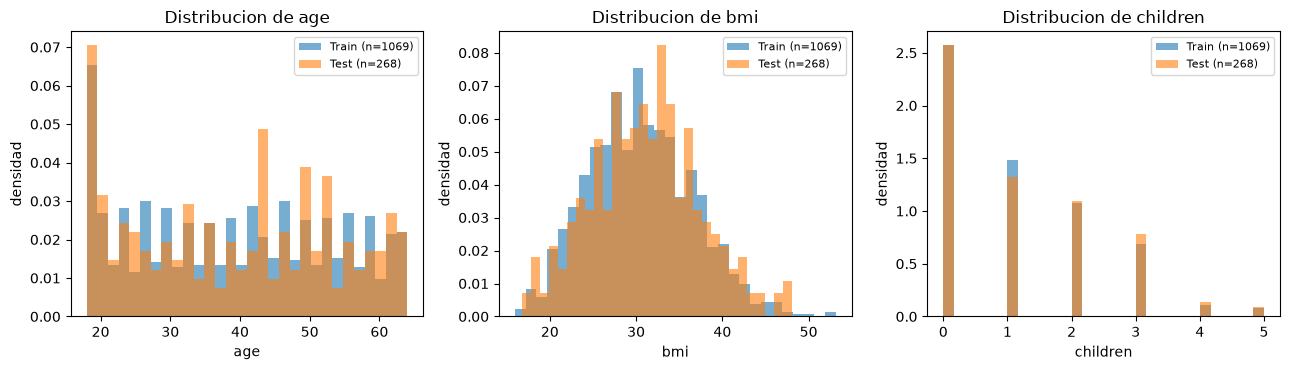

In [8]:
# Superponemos las distribuciones de las variables de entrada numericas.
# density=True normaliza las areas, para que ambos conjuntos sean comparables
# pese a tener distinto tamano.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

for ax, col in zip(axes, num_cols):
    ax.hist(train[col], bins=30, density=True, alpha=0.6, label=f"Train (n={len(train)})")
    ax.hist(test[col], bins=30, density=True, alpha=0.6, label=f"Test (n={len(test)})")
    ax.set_title(f"Distribucion de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("densidad")
    ax.legend(fontsize=8)

plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "01_distribucion_features_train_test.png", dpi=150, bbox_inches="tight")
plt.show()

**Lectura.** Las variables de entrada están bien repartidas: `age`, `bmi` y `children`
difieren poco entre train y test, las proporciones de las categóricas se mantienen dentro de
unos pocos puntos porcentuales (`smoker` queda en 20.0% en train contra 22.4% en test), y
los histogramas se superponen.

**El test es representativo de la muestra**..

---

## 3. Guardado de los splits


In [9]:
# Escribimos train.csv y test.csv en data/processed/.
guardar_splits(train, test)


---

## Conclusiones de la Fase 1

| Decisión | Valor | Motivo |
|---|---|---|
| Duplicados exactos | Eliminados antes del split (1 fila) | Evitar que una copia quede en train y otra en test |
| Momento del split | Antes de limpiar | Paso 3 del pipeline; evitar data leakage |
| Método | Muestreo aleatorio simple | Clase 3, slide 30 |
| Proporción | 80/20 → 1069 / 268 filas | Clase 3, slide 30 |
| Semilla | 42 | Reproducibilidad |
| Qué se observó del test | Sólo las variables de entrada | El target del test no se mira hasta la Fase 6 (Clase 2, slide 89) |

